In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import os
import psutil # Pastikan sudah install: pip install psutil

# Import dasar untuk SklearnWrapper
from sklearn.base import BaseEstimator, RegressorMixin

# Import model-model yang digunakan dalam base_estimators
from sklearn.ensemble import (StackingRegressor, RandomForestRegressor, 
                              ExtraTreesRegressor, GradientBoostingRegressor, 
                              AdaBoostRegressor)
from sklearn.linear_model import RidgeCV, Lasso
from sklearn.svm import SVR

# Import model pihak ketiga (pastikan sudah install: pip install xgboost lightgbm catboost)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

In [2]:
# 1. LOAD DATA
df = pd.read_excel('Dataset 3 ops + cems.xlsx')
X = df.drop(columns=['Boiler Eff (%)','NPHR (Kcal/Kwh)'])
y = df['Boiler Eff (%)']


In [3]:
df

,Main steam flow (t/h),Main steam temperature (boiler side) (℃),Main steam pressure (boiler side) (Mpa),Reheat steam temperature (boiler side) (℃),Superheater desuperheating water flow (t/h),Reheater desuperheating water flow (t/h),Feedwater temperature (℃),Feedwater flow (t/h),Flue gas temperature (℃),Boiler oxygen level (%),...,Coal Flow (t/h),NPHR (Kcal/Kwh),Gross Load (MW),Nett Load (MW),HHV (Kcal/Kg),Pressure HRH,Temperature HRH,Spray reheat pressure,Spray reheat temperature,Boiler Eff (%)
0,983.364461,568.098974,15.970471,566.719831,128.135595,0.935145,258.021498,1035.752935,130.708067,3.828501,...,192.41,2607.270106,344.56,323.93,4389.444444,2.29,566.36,5.50,159.91,77.915748
1,903.312848,568.023808,14.907765,563.985723,119.628420,1.944743,253.733859,964.867360,129.803971,3.659717,...,181.37,2687.121676,316.02,296.27,4389.444444,2.10,565.00,5.11,149.95,76.294873
2,903.734408,568.650337,14.869165,565.670929,110.785154,1.437433,253.613525,959.486415,127.860081,3.561764,...,178.47,2663.032090,314.22,294.17,4389.444444,2.09,565.63,5.08,149.38,77.886219
3,877.767639,568.262788,14.422768,564.237198,97.307475,0.983420,252.217335,938.427597,129.812856,3.905170,...,172.09,2651.943177,304.68,284.84,4389.444444,2.03,564.09,4.92,141.10,78.367624
4,921.238833,568.102547,15.204717,565.474856,93.665703,0.798093,254.271976,974.631602,130.218360,3.879849,...,181.74,2651.524408,320.94,300.86,4389.444444,2.13,565.75,5.23,148.33,77.856369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,963.383357,567.188810,15.563528,564.490362,89.382077,3.987283,257.473513,970.169352,124.009406,3.292357,...,172.99,2362.587163,329.71,310.26,4237.333333,2.22,565.60,5.37,155.64,89.855113
545,890.941643,567.664945,14.386963,565.543734,83.488775,1.646984,253.524998,895.883235,123.268547,3.498842,...,164.77,2421.984297,307.55,288.27,4237.333333,2.08,565.79,4.96,150.91,88.052730
546,882.807854,567.590635,14.158093,566.011767,102.147880,3.174934,252.915498,886.779790,124.640201,3.468605,...,169.38,2522.739965,303.77,284.50,4237.333333,2.05,565.84,4.84,149.64,85.018900
547,917.612111,567.520828,14.621877,566.072634,106.958025,6.522704,254.775243,915.165001,127.187321,3.320881,...,179.69,2584.543200,314.09,294.60,4237.333333,2.12,566.30,5.00,153.37,83.295960


In [4]:
# 2. SETUP EKSPERIMEN
sample_sizes = np.linspace(0.1, 1.0, 10) 
n_records = []
training_times = []
inference_times = []



In [5]:
# --- COMPATIBILITY WRAPPER (FIXED for sklearn 1.8.0 Tags system) ---
class SklearnWrapper(BaseEstimator, RegressorMixin):
    """Wrapper untuk kompatibilitas dengan sklearn StackingRegressor"""
    def __init__(self, model):
        self.model = model
    
    def fit(self, X, y, **fit_params):
        self.model.fit(X, y, **fit_params)
        return self
    
    def predict(self, X):
        return self.model.predict(X)
    
    def get_params(self, deep=True):
        return {"model": self.model}
    
    def set_params(self, **params):
        if "model" in params:
            self.model = params["model"]
        return self
    
    # Implement __sklearn_tags__ for proper regressor detection in sklearn 1.8.0+
    def __sklearn_tags__(self):
        from sklearn.utils._tags import Tags, RegressorTags, TargetTags, InputTags
        tags = Tags(
            estimator_type="regressor",
            target_tags=TargetTags(
                required=False,
                one_d_labels=False,
                two_d_labels=False,
                positive_only=False,
                multi_output=False,
                single_output=True
            ),
            regressor_tags=RegressorTags(),
            input_tags=InputTags()
        )
        return tags


# ==========================================
# 3. LOOPING UNTUK MENGUKUR WAKTU
# ==========================================
print(f"{'N':<8} | {'Train Time (s)':<15} | {'Inf Time (s)':<15}")
print("-" * 45)

# 3. LOOPING PENGUKURAN
for prop in sample_sizes:
    n = int(len(df) * prop)
    X_subset = X.iloc[:n]
    y_subset = y.iloc[:n]
    n_records.append(n)

    # ----------------------------------------------------
    # SETUP STACKING REGRESSOR
    # ----------------------------------------------------
    # 1. Definisikan Base Models (Sesuaikan dengan model di notebook Anda)
    # Contoh di bawah ini menggunakan Random Forest dan XGBoost
    base_estimators = [
   ('xgb', SklearnWrapper(xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42))),
    ('cat', SklearnWrapper(CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42))),
    ('lgbm', SklearnWrapper(lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, verbosity=-1, random_state=42))),
    ('rf', RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)),
    ('et', ExtraTreesRegressor(n_estimators=300, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=300, random_state=42)),
    ('ada', AdaBoostRegressor(n_estimators=100, random_state=42)),
    ('svr', SklearnWrapper(SVR(C=1.0, epsilon=0.1))),
    ('lasso', Lasso(alpha=0.01))
    ]
    
    # 2. Definisikan Final Estimator (Meta-model)
    final_estimator = RidgeCV()
    
    # 3. Gabungkan ke dalam StackingRegressor
    model = StackingRegressor(
        estimators=base_estimators,
        final_estimator=final_estimator,
        cv=5 # Menggunakan 5-fold cross validation saat melatih meta-model
    )
    # ----------------------------------------------------
    
    # --- PENGUKURAN TRAINING ---
    start_train = time.time()
    model.fit(X_subset, y_subset)
    end_train = time.time()
    training_times.append(end_train - start_train)

    # --- PENGUKURAN INFERENCE (DETEKSI) ---
    start_inf = time.time()
    model.predict(X_subset)
    end_inf = time.time()
    inference_times.append(end_inf - start_inf)

    print(f"{n:<8} | {training_times[-1]:<15.4f} | {inference_times[-1]:<15.4f}")

N        | Train Time (s)  | Inf Time (s)   
---------------------------------------------


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.262e+00, tolerance: 2.651e-02
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.525e-01, tolerance: 2.245e-02
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.970e-01, toler

54       | 6.3843          | 0.0261         


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.083e+00, tolerance: 8.752e-02
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.595e+00, tolerance: 6.887e-02
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.857e+00, toler

109      | 7.9636          | 0.0346         


...

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.351e+01, tolerance: 6.453e-01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.326e+01, tolerance: 3.855e-01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.111e+00, toler

494      | 35.3934         | 0.1048         


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.371e+01, tolerance: 6.831e-01
  model = cd_fast.enet_coordinate_descent(


549      | 31.6301         | 0.1003         


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.386e+01, tolerance: 4.060e-01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.333e-01, tolerance: 4.129e-01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.197e+01, toler

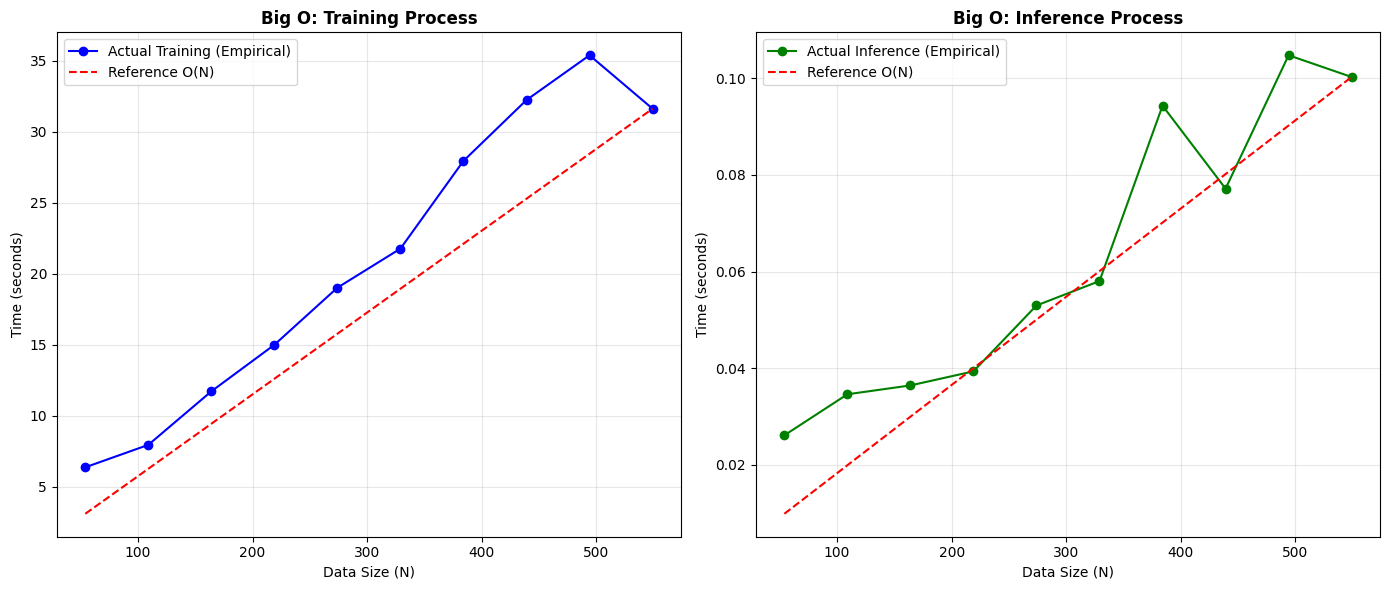

In [6]:
# 4. VISUALISASI PERBANDINGAN BIG O
plt.figure(figsize=(14, 6))

# Subplot 1: Training
plt.subplot(1, 2, 1)
plt.plot(n_records, training_times, 'bo-', label='Actual Training (Empirical)')
train_linear = [training_times[-1] * (n / n_records[-1]) for n in n_records]
plt.plot(n_records, train_linear, 'r--', label='Reference O(N)')
plt.title('Big O: Training Process', fontweight='bold')
plt.xlabel('Data Size (N)')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Inference
plt.subplot(1, 2, 2)
plt.plot(n_records, inference_times, 'go-', label='Actual Inference (Empirical)')
inf_linear = [inference_times[-1] * (n / n_records[-1]) for n in n_records]
plt.plot(n_records, inf_linear, 'r--', label='Reference O(N)')
plt.title('Big O: Inference Process', fontweight='bold')
plt.xlabel('Data Size (N)')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()